In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [9]:
df = pd.read_csv("fifa_data.csv")
drop_cols = ["Unnamed: 0", "ID", "Photo", "Flag", "Club Logo"]
fifa = df.drop(columns=[c for c in drop_cols if c in df.columns])
fifa.head()

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Special,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,2202,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,2228,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,2143,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,1471,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,2281,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [10]:
def height_to_cm(h):
    try:
        feet, inches = h.split("'")
        return int(feet) * 30.48 + int(inches) * 2.54
    except:
        return np.nan

def weight_to_kg(w):
    try:
        return int(w.replace("lbs", "")) * 0.453592
    except:
        return np.nan

def money_to_number(v):
    if pd.isna(v):
        return np.nan
    v = str(v).replace("€", "")
    if "M" in v:
        return float(v.replace("M", "")) * 1_000_000
    if "K" in v:
        return float(v.replace("K", "")) * 1_000
    return np.nan

fifa["Height_cm"] = fifa["Height"].astype(str).apply(height_to_cm)
fifa["Weight_kg"] = fifa["Weight"].astype(str).apply(weight_to_kg)
fifa["Wage_EUR"] = fifa["Wage"].apply(money_to_number)
fifa["Value_EUR"] = fifa["Value"].apply(money_to_number)

fifa.head()

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Special,Preferred Foot,...,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,Height_cm,Weight_kg,Wage_EUR,Value_EUR
0,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,2202,Left,...,6.0,11.0,15.0,14.0,8.0,€226.5M,170.18,72.121128,565000.0,110500000.0
1,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,2228,Right,...,7.0,11.0,15.0,14.0,11.0,€127.1M,187.96,83.007336,405000.0,77000000.0
2,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,2143,Right,...,9.0,9.0,15.0,15.0,11.0,€228.1M,175.26,68.038800,290000.0,118500000.0
3,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,1471,Right,...,90.0,85.0,87.0,88.0,94.0,€138.6M,193.04,76.203456,260000.0,72000000.0
4,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,2281,Right,...,15.0,13.0,5.0,10.0,13.0,€196.4M,180.34,69.853168,355000.0,102000000.0


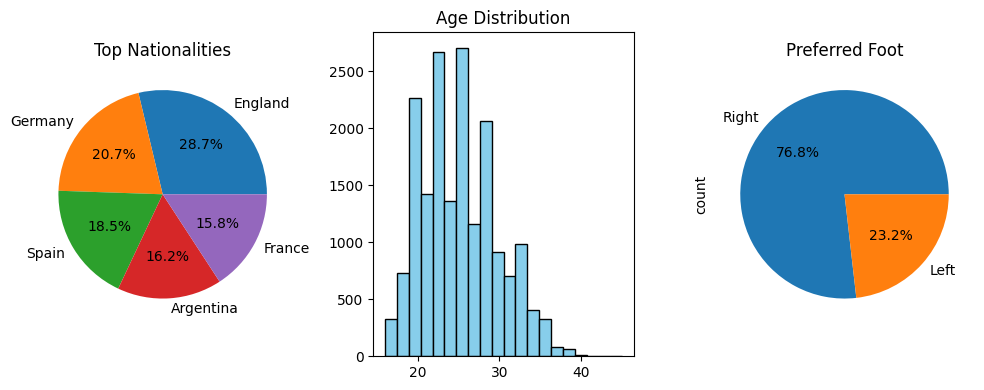

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
counts = fifa["Nationality"].value_counts().head(5)
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Top Nationalities")

plt.subplot(1, 3, 2)
plt.hist(fifa["Age"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")

plt.subplot(1, 3, 3)
fifa["Preferred Foot"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Preferred Foot")

plt.tight_layout()
plt.show()

In [12]:
features = [
    "Age", "Height_cm", "Weight_kg",
    "Acceleration", "SprintSpeed", "Stamina", "Strength"
]
target = "Overall"

ml_df = fifa[features + [target]].dropna()

X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest R²: {r2_score(y_test, rf_pred):.3f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print(f"XGBoost R²: {r2_score(y_test, xgb_pred):.3f}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f}")

Random Forest R²: 0.424
Random Forest RMSE: 5.21
XGBoost R²: 0.457
XGBoost RMSE: 5.06


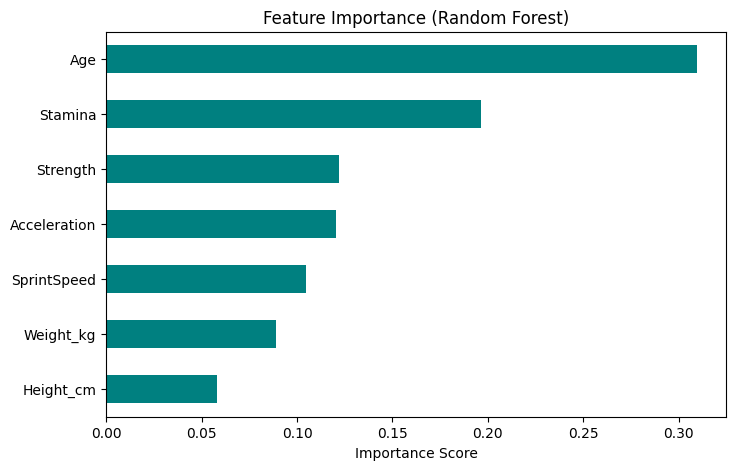

In [13]:
importances = pd.Series(rf.feature_importances_, index=features)
plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh", color="teal")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()